# Generate time series and map subsiding areas in OPERA DISP-S1 products
---    

### Data Used in the Example:   

- **Provisional OPERA Level 3 Surface Displacement (DISP-S1) Product from Sentinel-1 at 30m Resolution over North America**
    - The OPERA Level 3 Land-Surface Displacement (L3_DISP) product is generated from a sequence of the Level 2 Coregistered Single Look Complex (L2_CSLC) products derived from Sentinel-1AB (S1) satellites. The OPERA project aims to produce high-quality Interferometric Synthetic Aperture Radar (InSAR)-derived displacement data with reduced decorrelation noise using a hybrid Persistent Scatterer (PS) and Distributed Scatterer (DS) time series processing approach [[dolphin](https://joss.theoj.org/papers/10.21105/joss.06997)]. The displacement product provides information on anthropogenic and natural changes of Earth's surface, such as subsidence, tectonics, and landslides.
    
    - The OPERA project is generating geocoded DISP-S1 products over North America which includes USA and US Territories within 200 km from the US border, Canada, and all mainland countries from the southern US border down to and including Panama. Each pixel within a DISP-S1 frame contains geocoded displacement as well as quality layers information.

    - For more information about the OPERA project and other products please visit our website at https://www.jpl.nasa.gov/go/opera .

---

### OPERA DISP-S1 Data Architecture Overview

The OPERA DISP-S1 products are designed to simplify time series InSAR analysis for a wide user base. Key components of the DISP-S1 architecture:

- **Ministack Structure**  
  - Each file represents cumulative displacement between a fixed reference date** and a specific secondary date
  - A **ministack** includes up to **15 acquisitions**: all files share the same reference date and have different secondary dates  
  - The **last file** in a ministack contains the **total cumulative displacement** from the reference date to the final (15th) secondary date

- **Sequential Ministacks**  
  - The **last secondary date of one ministack becomes the reference date** for the next ministack  
  - This creates a chain of overlapping stacks, where each new ministack starts at zero and spans the next 15 acquisitions

- **Spatial Referencing**  
  - Data is projected in the UTM zone appropriate to each frame  
  - Gridded at **30 m resolution**

- **Data Format & Layers**  
  - Provided as NetCDF files using CF-1.8 conventions
  - Contain:
    - Primary displacement data (`displacement`)
    - Quality metrics (`temporal_coherence`, `phase_similarity`, etc.)
    - Ancillary layers (`recommended_mask`, `water_mask`, `persistent_scatterer_mask`, etc.)
    - Spatial metadata (projection, pixel spacing, etc.)

- **Coverage & Frequency**  
  - Data available over North America, with a 6- to 12-day revisit depending on Sentinel-1 satellite orbit configuration  
  - Products are released as provisional, pending further validation

---

### OPERA DISP-S1 File Naming Convention

Each DISP-S1 product file follows a standardized naming pattern that encodes key metadata directly in the filename.

#### Example:
**OPERA_L3_DISP-S1_IW_F11116_VV_20240406T140838Z_20241003T140837Z_v1.1_20250220T140455Z.nc**

#### Field Descriptions:
- `OPERA_L3_DISP-S1` — OPERA Level-3 Displacement product from Sentinel-1
- `IW` — Interferometric Wide swath mode (Sentinel-1 acquisition mode)
- `<FRAMEID>` — Unique frame identifier (e.g., `F11116`)
- `<POL>` — Polarization used (`VV` or `VH`)
- `<REFDATE>` — Start date of the time series (reference date)
- `<SECONDDATE>` — End date of the time series (last acquisition in ministack)
- `<VERSION>` — Product version (e.g., `v1.1`)
- `<COMPUTEDATE>` — Date the product was generated

#### Notes:
- All displacement values in the file are **cumulative**, measured from `<REFDATE>` to `<SECONDDATE>`.
- Products with different `<REFDATE>` values represent separate ministacks.


Please refer to the [OPERA Product Specification Document](https://d2pn8kiwq2w21t.cloudfront.net/documents/OPERA_DISP_S1_Final_Product_Spec.pdf) for more details about the DISP-S1 products.

*Prepared by B. Raimbault*
</div>

## Setup your conda environment

Assuming you have [miniconda](https://docs.conda.io/projects/miniconda/en/latest/miniconda-install.html) or conda installed. Open your terminal and run the following:
```
> conda create -n opera_disp-s1
> conda activate opera_disp-s1
> conda install -c conda-forge python==3.11.13 jupyter ipyleaflet
>  jupyter-notebook /path/to/your.file/Intro_to_DISP-S1.ipynb
```

---    

## Import Libraries

In [1]:
import os
import subprocess
import sys

def run(cmd):
    """Run a shell command silently."""
    subprocess.run(cmd, shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

def install_dependencies():
    """Clone and install MintPy and disp-xr with necessary adjustments."""
    run("git clone https://github.com/insarlab/MintPy.git")
    run("pip install -e ./MintPy")

    run("git clone https://github.com/opera-adt/disp-xr.git")
    run("pip install -e ./disp-xr")
    
    run("pip install matplotlib ipykernel pandas rasterio rioxarray asf_search opera_utils zarr s3fs dem_stitcher tile_mate contextily h5netcdf h5py ipyleaflet ipywidgets jupyter-leaflet")
    sys.path.insert(0, "disp-xr/src")
    sys.path.insert(0, "MintPy/src")
    print("All dependencies installed successfully.")

install_dependencies()

All dependencies installed successfully.


In [2]:
import base64
import glob
import os
import subprocess
import sys
from getpass import getpass
from io import BytesIO
from netrc import netrc, NetrcParseError
from platform import system

import contextily as cx
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyproj
import rasterio as rasterio
import xarray as xr
from IPython.display import Markdown, display
from ipyleaflet import Map, ImageOverlay, LayersControl, basemaps, TileLayer, basemap_to_tiles, Rectangle, WidgetControl
from ipywidgets import Layout, VBox, Image as IPyImage, HTML, link
from matplotlib import cm, colorbar, ticker
from skimage import exposure
from skimage.color import rgb2gray
### Third party library import -- https://github.com/opera-adt/disp-xr
from disp_xr import product, stack as disp_stack, quality_metrics


## Science Dataset Example: San Simon / Bowie Subsidence in Arizona
Arizona has experienced significant land subsidence since the early 20th century, primarily due to groundwater extraction and the resulting compaction of alluvial sediments. 
This compaction occurs when declining water tables reduce pore pressure, causing the land surface to sink irreversibly. 
Subsidence can lead to the formation of earth fissures—long cracks in the ground that can cause extensive damage to infrastructure and property.

One of the well-known subsidence zones in Arizona is the San Simon / Bowie basin, located in southeastern Arizona. This region has been the focus of long-term monitoring by the Arizona Department of Water Resources (ADWR) using advanced geodetic tools like, GPS, levelling and InSAR (Interferometric Synthetic Aperture Radar).

### Define the Area of Interest
In this notebook, we focus on the San Simon / Bowie land subsidence feature (see [ADWR’s official map and data](https://www.azwater.gov/hydrology/land-subsidence/bowiesan-simon-land-subsidence-feature)).

We use DISP-S1 InSAR products from January 2022 to September 2024 (e.g., Frame 34478) to construct a time series of ground deformation. 
This subset enables us to analyze the rate and extent of ongoing subsidence driven by continued groundwater withdrawal.
By tracking the temporal and spatial patterns of land movement, we contribute to a broader understanding of subsidence hazards, resource management, and long-term environmental monitoring in arid basins.

In [4]:
# Define the frame ID for the dataset
# This ID corresponds to the specific dataset you want to work with
FRAME_ID = 34478

# Define the Area of Interest (AOI) using a bounding box
# AOI -- {'lon_min': -109.557301, 'lon_max': -109.03012, 'lat_min': 32.153525, 'lat_max': 32.456474}
BBOX = "-109.557301 32.153525 -109.03012 32.456474"

# Define the start and end dates for the data collection
start_date = '2022-01-01'
end_date = '2024-09-15'

# Define the number of workers for parallel processing
N_WORKERS = 4

## Setup your Earthdata credentials
To download DISP-S1 products, you need to authenticate with NASA's Earthdata system, since the data is hosted on the Earthdata repository.

The following cell will prompt you to enter your **NASA Earthdata Login** credentials. This information is saved in a `.netrc` file, enabling authenticated access for data downloads during this session.

<font color="red">If the .netrc file already exists and contains valid credentials, this step will run silently without prompting.</font> 

<font color="red">After that, type your NASA Earthdata username, press Enter, then type your password and press Enter again.</font>  

<font color="red">If you make a mistake or if the following cells show download errors, rerun this cell and ensure the credentials are entered correctly.</font>

🔐 You can register for a free NASA Earthdata account here: [https://urs.earthdata.nasa.gov/](https://urs.earthdata.nasa.gov/)


In [5]:
urs = 'urs.earthdata.nasa.gov'
prompts = ['Enter NASA Earthdata Login Username: ',
           'Enter NASA Earthdata Login Password: ']

netrc_name = "_netrc" if system() == "Windows" else ".netrc"
netrc_path = os.path.expanduser(f"~/{netrc_name}")

def write_netrc():
    username = getpass(prompt=prompts[0])
    password = getpass(prompt=prompts[1])
    with open(netrc_path, 'a') as f:
        f.write(f"\nmachine {urs}\n")
        f.write(f"login {username}\n")
        f.write(f"password {password}\n")
    os.chmod(netrc_path, 0o600)

def has_urs_credentials():
    try:
        creds = netrc(netrc_path).authenticators(urs)
        return creds is not None
    except (FileNotFoundError, NetrcParseError):
        return False

if not has_urs_credentials():
    if not os.path.exists(netrc_path):
        open(netrc_path, 'w').close()
    write_netrc()


## Download Cropped DISP-S1 Data

In [6]:
%env BBOX=$BBOX
%env FRAME_ID=$FRAME_ID
%env START=$start_date
%env END=$end_date
%env NUM_WORKERS=$N_WORKERS

!opera-utils disp-s1-download \
    --output-dir subset-ncs \
    --bbox $BBOX \
    --frame-id $FRAME_ID \
    --start-datetime $START \
    --end-datetime $END \
    --num-workers $NUM_WORKERS

env: BBOX=-109.557301 32.153525 -109.03012 32.456474
env: FRAME_ID=34478
env: START=2022-01-01
env: END=2024-09-15
env: NUM_WORKERS=4
Found 80 urls for Frame 34478
Subsetting to Rows: slice(1281, 2375, None), cols: slice(6172, 7844, None)
100%|███████████████████████████████████████████| 80/80 [15:16<00:00, 11.46s/it]


## Ministack Structure and Layers

This step sets up the workspace for your selected DISP-S1 frame. It then displays a scatter plot of available acquisition pairs, based on the downloaded granules.

In DISP-S1:
- A ministack consists of up to 15 acquisition dates
- All displacements are measured **relative to a fixed reference date**
- The plot shows:
  - **x-axis**: reference date (the same across the stack)
  - **y-axis**: each secondary date paired with that reference
- This results in a vertical alignment of dots in the scatter plot with one column per ministack

Each point represents a pair of dates over which cumulative displacement is measured from the reference.

v1.0, size: 80


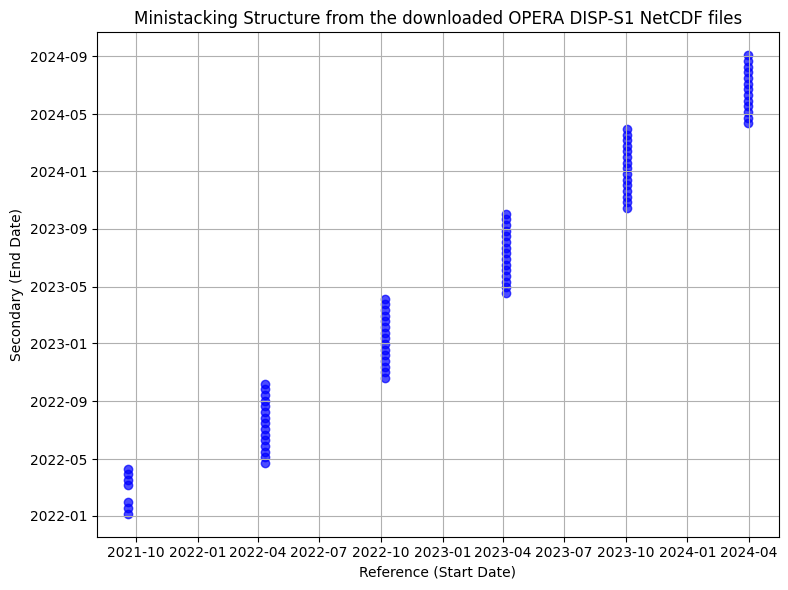

Files information:


,project,level,product,mode,frame_id,polarizarion,start_date,end_date,version,production_date,path,date12,date1,date2
0,OPERA,L3,DISP-S1,IW,F34478,VV,2021-09-19 13:20:20,2022-01-05 13:20:17,v1.0,20250418T235117Z,subset-ncs/OPERA_L3_DISP-S1_IW_F34478_VV_20210...,20210919_20220105,20210919,20220105
1,OPERA,L3,DISP-S1,IW,F34478,VV,2021-09-19 13:20:20,2022-01-17 13:20:17,v1.0,20250418T235117Z,subset-ncs/OPERA_L3_DISP-S1_IW_F34478_VV_20210...,20210919_20220117,20210919,20220117
2,OPERA,L3,DISP-S1,IW,F34478,VV,2021-09-19 13:20:20,2022-01-29 13:20:17,v1.0,20250418T235117Z,subset-ncs/OPERA_L3_DISP-S1_IW_F34478_VV_20210...,20210919_20220129,20210919,20220129
3,OPERA,L3,DISP-S1,IW,F34478,VV,2021-09-19 13:20:20,2022-03-06 13:20:16,v1.0,20250418T235117Z,subset-ncs/OPERA_L3_DISP-S1_IW_F34478_VV_20210...,20210919_20220306,20210919,20220306
4,OPERA,L3,DISP-S1,IW,F34478,VV,2021-09-19 13:20:20,2022-03-18 13:20:16,v1.0,20250418T235117Z,subset-ncs/OPERA_L3_DISP-S1_IW_F34478_VV_20210...,20210919_20220318,20210919,20220318
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,OPERA,L3,DISP-S1,IW,F34478,VV,2024-03-31 13:20:28,2024-07-17 13:20:26,v1.0,20250420T161742Z,subset-ncs/OPERA_L3_DISP-S1_IW_F34478_VV_20240...,20240331_20240717,20240331,20240717
76,OPERA,L3,DISP-S1,IW,F34478,VV,2024-03-31 13:20:28,2024-07-29 13:20:26,v1.0,20250420T161742Z,subset-ncs/OPERA_L3_DISP-S1_IW_F34478_VV_20240...,20240331_20240729,20240331,20240729
77,OPERA,L3,DISP-S1,IW,F34478,VV,2024-03-31 13:20:28,2024-08-10 13:20:26,v1.0,20250420T161742Z,subset-ncs/OPERA_L3_DISP-S1_IW_F34478_VV_20240...,20240331_20240810,20240331,20240810
78,OPERA,L3,DISP-S1,IW,F34478,VV,2024-03-31 13:20:28,2024-08-22 13:20:26,v1.0,20250420T161742Z,subset-ncs/OPERA_L3_DISP-S1_IW_F34478_VV_20240...,20240331_20240822,20240331,20240822


In [6]:
# Load displacement info from the directory
nc_dir = "subset-ncs"
disp_df = product.get_disp_info(nc_dir)

# Group by version
versions = {}
for version in disp_df["version"].unique():
    df = disp_df[disp_df["version"] == version].copy()
    versions[version] = df
    print(f"{version}, size: {df.shape[0]}")

# Plot Date1 vs Date2 for each version
for version, df in versions.items():
    df["date1"] = pd.to_datetime(df["date1"], format="%Y%m%d")
    df["date2"] = pd.to_datetime(df["date2"], format="%Y%m%d")

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(df["date1"], df["date2"], alpha=0.7, marker="o", color="b")
    ax.set_xlabel("Reference (Start Date)")
    ax.set_ylabel("Secondary (End Date)")
    ax.set_title("Ministacking Structure from the downloaded OPERA DISP-S1 NetCDF files")
    ax.grid(True)
    plt.tight_layout()
    plt.show()
    
print('Files information:')
disp_df

## Visualize the displacement contained in one file

What you'll see on the following maps is the displacement value for the last file in the stack, meaning it shows the cumulative deformation between the two dates (2024-03-31 to 2024-09-03).

- The left panel shows the displacement in **UTM coordinates**, which maintains the original projection of the dataset.
- The right panel shows the same displacement data but **reprojected to geographic coordinates (EPSG:4326)**, using latitude and longitude.

- Colors represent motion in the satellite's line-of-sight (LOS) direction  
  - **Red** indicates motion **away** from the satellite  
  - **Blue** indicates motion **toward** the satellite

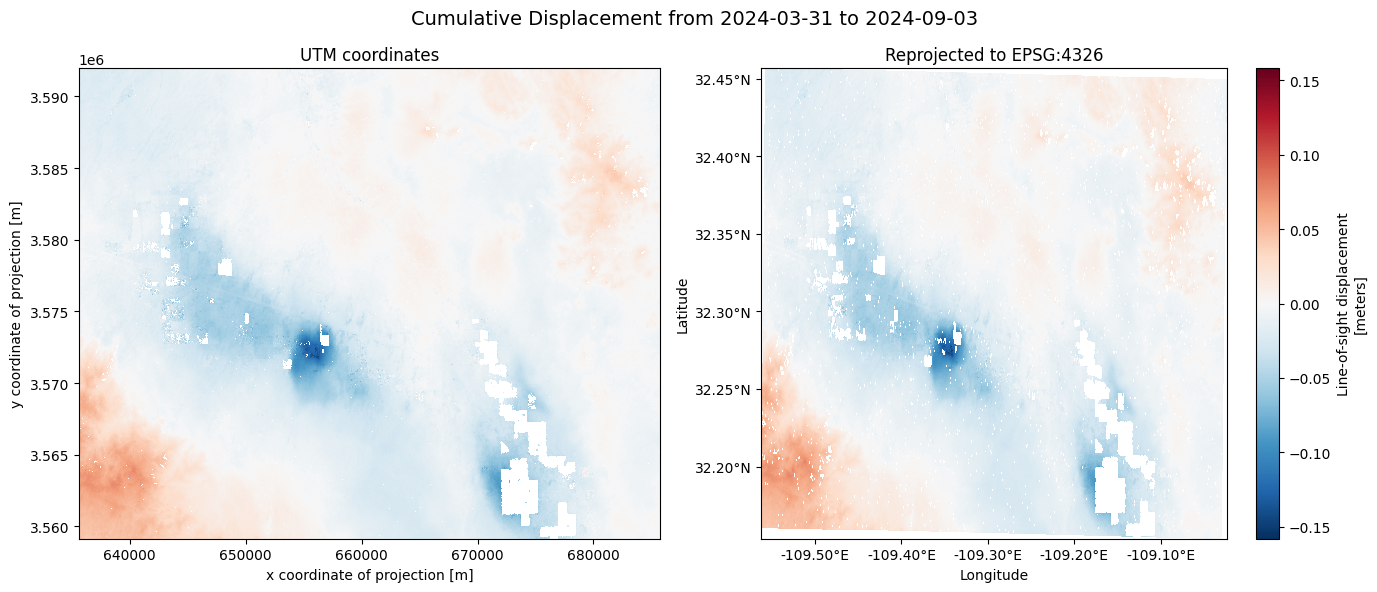

In [7]:
# Load last file
row = disp_df.iloc[-1]
ds = xr.open_dataset(row.path, chunks={"time": 1})

# Format dates
d1 = pd.to_datetime(row.date1, format="%Y%m%d").date()
d2 = pd.to_datetime(row.date2, format="%Y%m%d").date()
title = f"Cumulative Displacement from {d1} to {d2}"

# Mask displacement
da = ds.where(ds.recommended_mask == 1).isel(time=-1).displacement

# Reproject to lat/lon
da.rio.write_crs(pyproj.CRS(ds.spatial_ref.attrs['crs_wkt']).to_epsg(), inplace=True)
da.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=True)
da_4326 = da.rio.reproject("EPSG:4326", resampling=rasterio.enums.Resampling.bilinear)

# Plot side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: UTM
da.plot.imshow(ax=ax1, cmap="RdBu_r", add_colorbar=False)
ax1.set_title("UTM coordinates")

# Right: Lat/Lon
im = da_4326.plot.imshow(ax=ax2, cmap="RdBu_r", add_colorbar=True)
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.2f}°E"))
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:.2f}°N"))
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
ax2.set_title("Reprojected to EPSG:4326")

# Shared title and layout
fig.suptitle(title, fontsize=14)
plt.tight_layout()
plt.show()


## Stacking the OPERA DISP-S1 Files

The `stack_prod` object is an `xarray.Dataset` that represents the full stack of DISP-S1 data loaded from the downloaded DISP-S1 NetCDF files.

As shown below, the dataset includes:
- **Coordinates**: spatial (x, y) and temporal (time) axes
- **Data variables**: multiple layers beyond just displacement
- **Attributes**: metadata describing the product version, projection, mission, and contact info

While the **`displacement`** variable is the main product of interest (cumulative surface motion in the LOS from the reference date), DISP-S1 products also include a variety of **supporting layers**.

<font color="red">📌 A more detailed explanation of each layer will be provided later in the notebook.</font>


In [8]:
stack_prod = disp_stack.combine_disp_product(disp_df)
epsg = pyproj.CRS(stack_prod.spatial_ref.attrs['crs_wkt']).to_epsg()
print('Stack information:')
print(stack_prod)

Stack information:
<xarray.Dataset> Size: 7GB
Dimensions:                         (time: 81, y: 1094, x: 1672)
Coordinates:
  * y                               (y) float64 9kB 3.592e+06 ... 3.559e+06
  * x                               (x) float64 13kB 6.356e+05 ... 6.858e+05
  * time                            (time) datetime64[ns] 648B 2021-09-19T13:...
Data variables: (12/13)
    spatial_ref                     (time) int64 648B 0 0 0 0 0 0 ... 0 0 0 0 0
    reference_time                  (time) datetime64[ns] 648B dask.array<chunksize=(1,), meta=np.ndarray>
    displacement                    (time, y, x) float32 593MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    short_wavelength_displacement   (time, y, x) float32 593MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    recommended_mask                (time, y, x) float32 593MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    connected_component_labels      (time, y, x) float32 593MB dask.array<chunksize

## Selecting a Reference Point for Displacement

InSAR displacement measurements are **relative in both space and time**. They show movement **with respect to a chosen reference point**.  
To interpret the displacement meaningfully, we need to define a point that is assumed to be:
- Not moving during the observed time period  
- Or located near your area of interest or object, to capture differential motion relative to it

The reference point will serve as the zero-displacement baseline, and all other pixel values in the stack will be computed relative to it.
It means that if this points is noisy or unreliable, every other pixels will be affected.

<font color="red"> Choosing a good reference is important: a stable or nearby point helps isolate the motion you're investigating.</font>

In [9]:
# Lat/lon of the reference point
lat, lon = 32.3409, -109.3661

# Convert to UTM
epsg = pyproj.CRS(stack_prod.spatial_ref.attrs["crs_wkt"]).to_epsg()
proj = pyproj.Transformer.from_crs("EPSG:4326", f"EPSG:{epsg}", always_xy=True)
ref_x, ref_y = proj.transform(lon, lat)

# Subtract reference
ref_disp = stack_prod.sel(x=ref_x, y=ref_y, method='nearest').displacement
stack_prod['displacement'] = stack_prod.displacement - ref_disp

## Visualize Cumulative Displacement Relative to Reference Point

The following map shows the cumulative displacement from the first reference date to the last acquisition date in the stack:
- Colors represent motion in the satellite's line-of-sight (LOS) direction  
  - **Red** indicates motion **away** from the satellite  
  - **Blue** indicates motion **toward** the satellite
- The green dot marks the **reference point**, which has been set to zero displacement
- The values are in **centimeters**, relative to that reference

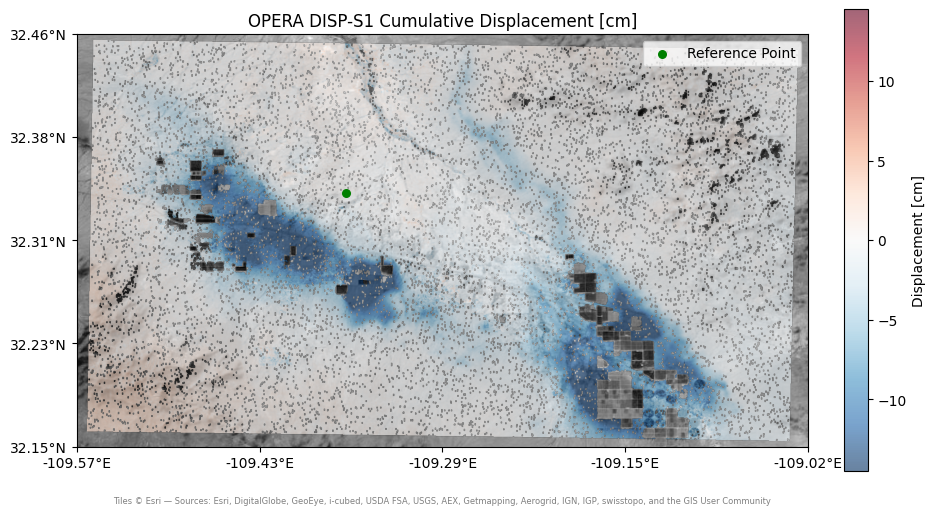

In [10]:
def get_baseimage_from_bounds(bounds, source, grayscale=False, gamma=None, log=None, zoom='auto'):
    xmin, ymin, xmax, ymax = bounds
    left, right, bottom, top = cx.plotting._reproj_bb(xmin, xmax, ymin, ymax, 'EPSG:4326', "epsg:3857")
    image, extent = cx.tile.bounds2img(left, bottom, right, top, zoom=zoom, source=source, ll=False)
    image, extent = cx.tile.warp_tiles(image, extent, t_crs='EPSG:4326', resampling=rasterio.enums.Resampling.bilinear)
    if grayscale:
        image = rgb2gray(image[:, :, :3])
    if gamma is not None:
        image = exposure.adjust_gamma(image, gamma)
    if log is not None:
        image = exposure.adjust_log(image, log)
    return image, extent

# Preprocess displacement
buffer_fraction = 0.015
da = stack_prod.isel(time=-1).displacement * 100  # cm
mask = stack_prod.isel(time=-1).recommended_mask
water = stack_prod.isel(time=-1).water_mask
da = da.where((mask == 1) & (water == 1))

# Set CRS and reproject
da.rio.write_crs(epsg, inplace=True)
da.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=True)
da_4326 = da.rio.reproject("EPSG:4326", resampling=rasterio.enums.Resampling.bilinear)

# Buffer bounds
xmin, ymin, xmax, ymax = da_4326.rio.bounds()
x_pad = (xmax - xmin) * buffer_fraction
y_pad = (ymax - ymin) * buffer_fraction
buffered_bounds = [xmin - x_pad, ymin - y_pad, xmax + x_pad, ymax + y_pad]
extent = [buffered_bounds[0], buffered_bounds[2], buffered_bounds[1], buffered_bounds[3]]

# Normalize
v = np.nanpercentile(da_4326.values, [2, 98])
vmax = max(abs(v[0]), abs(v[1]))
vmin = -vmax

# Plot setup
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])

# Add basemap
bg, bg_extent = get_baseimage_from_bounds(buffered_bounds, source=cx.providers.Esri.WorldImagery, grayscale=True, gamma=0.9)
ax.imshow(bg, extent=bg_extent, cmap="gray", origin="upper", zorder=1)

# Displacement overlay
ax.imshow(da_4326.values, extent=[xmin, xmax, ymin, ymax], cmap=plt.get_cmap("RdBu_r"), vmin=vmin, vmax=vmax, alpha=0.6, origin="upper", zorder=2)

# Reference point
ax.scatter(lon, lat, color="green", s=30, label="Reference Point", zorder=3)

# Colorbar
cbar = plt.colorbar(ax.images[1], ax=ax, shrink=0.6, pad=0.04)
cbar.set_label("Displacement [cm]")

# Add ticks
ax.set_xticks(np.linspace(extent[0], extent[1], 5))
ax.set_yticks(np.linspace(extent[2], extent[3], 5))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.2f}°E"))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:.2f}°N"))
ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)

# Attribution
ax.annotate(
    "Tiles © Esri — Sources: Esri, DigitalGlobe, GeoEye, i-cubed, USDA FSA, USGS, AEX, "
    "Getmapping, Aerogrid, IGN, IGP, swisstopo, and the GIS User Community",
    xy=(0.5, -0.12), xycoords='axes fraction',
    ha='center', va='top', fontsize=6, color='gray'
)

ax.legend()
ax.set_title("OPERA DISP-S1 Cumulative Displacement [cm]")
plt.tight_layout()
plt.show()


## Interactive Visualisation of Cumulative Displacement Relative to Reference Point with Ipyleaflet

The following map shows the cumulative displacement from the first reference date to the last acquisition date in the stack:
- Colors represent motion in the satellite's line-of-sight (LOS) direction  
  - **Red** indicates motion **away** from the satellite  
  - **Blue** indicates motion **toward** the satellite
- The green dot marks the **reference point**, which has been set to zero displacement
- The values are in **centimeters**, relative to that reference

In [11]:
# Preprocess displacement
da = stack_prod.isel(time=-1).displacement * 100
mask = stack_prod.isel(time=-1).recommended_mask
water = stack_prod.isel(time=-1).water_mask
da = da.where((mask == 1) & (water == 1))

# Reproject
da.rio.write_crs(epsg, inplace=True)
da.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=True)
da_3857 = da.rio.reproject("EPSG:3857", resampling=rasterio.enums.Resampling.bilinear)

# Colormap
v = np.nanpercentile(da_3857.values, [2, 98])
vmax = max(abs(v[0]), abs(v[1]))
vmin = -vmax
cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad(color=(0, 0, 0, 0))

# Create colorbar image in buffer
fig_cb, ax_cb = plt.subplots(figsize=(4, 0.3), dpi=150)
norm = plt.Normalize(vmin=vmin, vmax=vmax)
cb = colorbar.ColorbarBase(ax_cb, cmap=cmap, norm=norm, orientation='horizontal')
cb.set_label("Displacement [cm]")
ax_cb.set_frame_on(False)

colorbar_buf = BytesIO()
fig_cb.savefig(colorbar_buf, format='png', bbox_inches='tight', transparent=True)
plt.close(fig_cb)
colorbar_buf.seek(0)

# Make colorbar ipywidget
colorbar_widget = IPyImage(
    value=colorbar_buf.read(),
    format='png',
    layout=Layout(margin='0 auto', display='block')  # Center the image
)

# Map image buffer
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
ax.axis("off")
ax.imshow(da_3857.values, vmin=vmin, vmax=vmax, cmap=cmap, origin="upper")
buf = BytesIO()
fig.savefig(buf, format="png", bbox_inches="tight", pad_inches=0, transparent=True)
plt.close(fig)
buf.seek(0)

# Lat/Lon bounds
west, south, east, north = da_3857.rio.bounds()
lon_west, lat_south = pyproj.Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True).transform(west, south)
lon_east, lat_north = pyproj.Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True).transform(east, north)
center_lon, center_lat = pyproj.Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True).transform(
    (west + east) / 2, (south + north) / 2
)

mapnik = basemap_to_tiles(basemaps.OpenStreetMap.Mapnik)
mapnik.base = True
mapnik.name = 'Mapnik Layer'

topo = basemap_to_tiles(basemaps.OpenTopoMap)
topo.base = True
topo.name = 'OpenTopo Layer'

Esritopo = basemap_to_tiles(basemaps.Esri.WorldTopoMap)
Esritopo.base = True
Esritopo.name = 'EsriTopo Layer'

Esri = basemap_to_tiles(basemaps.Esri.WorldImagery)
Esri.base = True
Esri.name = 'Esri World Imagery'

# Map
m = Map(
    center=(center_lat, center_lon),
    zoom=12,
    scroll_wheel_zoom=True,
    #basemap=basemaps.Esri.WorldImagery,
    layers = [mapnik, topo, Esritopo, Esri],
    layout=Layout(width="100%", height="700px")
)

overlay = ImageOverlay(
    url='data:image/png;base64,' + base64.b64encode(buf.read()).decode('utf-8'),
    bounds=((lat_south, lon_west), (lat_north, lon_east)),
    opacity=0.6,
    name="OPERA DISP-S1 Cumulative Displacement [cm]",
    attribution="Data: OPERA DISP-S1, Map: Esri World Imagery"
)


m.add_layer(overlay)
# Add control to toggle layers
m.add_control(LayersControl(position='topleft'))

d1 = pd.to_datetime(disp_df["date1"].iloc[0], format="%Y%m%d").date()
d2 = pd.to_datetime(disp_df["date2"].iloc[-1], format="%Y%m%d").date()

# Title widget
title_html = HTML(
    value=f"<h1 style='text-align:center;'>OPERA DISP-S1 Cumulative Displacement from {d1} to {d2}</h1>",
    layout=Layout(margin='0 0 5px 0')
)

# MiniMap Setup
mini_map = Map(
    zoom_control=False,
    attribution_control=False,
    center=m.center,
    zoom=max(m.zoom - 4, 1),
    basemap=basemap_to_tiles(basemaps.OpenStreetMap.Mapnik),
    layout=Layout(width="150px", height="150px")
)

data_bounds_rect = Rectangle(
    bounds=((lat_south, lon_west), (lat_north, lon_east)),
    color="red",
    fill_opacity=0.15,
    weight=2
)
mini_map.add_layer(data_bounds_rect)

# Dynamic update: Keep minimap in sync with main map
def update_minimap_view(change):
    mini_map.center = m.center
    mini_map.zoom = max(m.zoom - 4, 1)

m.observe(update_minimap_view, names=["center", "zoom", "bounds"])

# Add minimap to main map
minimap_control = WidgetControl(widget=mini_map, position="bottomleft")
m.add(minimap_control)

# Display everything
VBox([title_html, colorbar_widget, m])




## Plot a time series

The following cell allows you to select a point on the map and plot its associated displacement time series.

**Note**:
- If you select the reference point, the plot should display only zeros, because **all displacement is measured relative to this reference point**.
- As you move farther away from the reference point, the data may appear noisier, due to spatial decorrelation and atmospheric effects.
- The **first date** in the time series serves as the **temporal reference**, meaning all displacement values are relative to this initial timestamp.


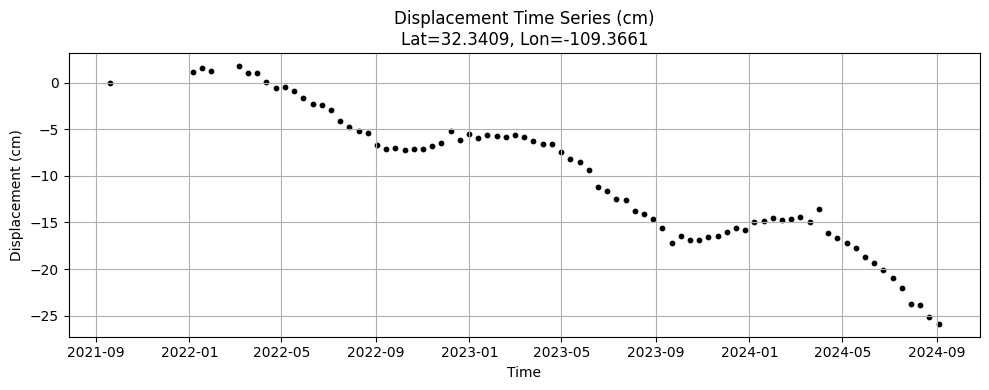

In [12]:
# Define the target point
tslat = 32.280239, 
tslon = -109.345905  

# Get EPSG from dataset
proj = pyproj.Transformer.from_crs("EPSG:4326", f"EPSG:{epsg}", always_xy=True)
x_click, y_click = proj.transform(tslon, tslat)

# Find nearest grid point
x_coords = stack_prod.x.values
y_coords = stack_prod.y.values
x_nearest = x_coords[np.argmin(np.abs(x_coords - x_click))]
y_nearest = y_coords[np.argmin(np.abs(y_coords - y_click))]
distance = np.sqrt((x_click - x_nearest)**2 + (y_click - y_nearest)**2)

# Check distance threshold
if distance > 100:
    print(f"Point too far from valid pixel (distance = {distance:.1f} m)")
else:
    # Check masks
    mask_val = stack_prod.sel(x=x_nearest, y=y_nearest, method="nearest").isel(time=-1).recommended_mask.values
    water_val = stack_prod.sel(x=x_nearest, y=y_nearest, method="nearest").isel(time=-1).water_mask.values

    if mask_val != 1 or water_val != 1:
        print("Selected point is masked out or on water.")
    else:
        # Get displacement
        disp = stack_prod.sel(x=x_nearest, y=y_nearest, method="nearest").displacement
        # Plot time series
        dates = pd.to_datetime(stack_prod.time.values)
        plt.figure(figsize=(10, 4))
        plt.scatter(dates, disp.values * 100, s=10, color='black')
        plt.title(f"Displacement Time Series (cm)\nLat={lat:.4f}, Lon={lon:.4f}")
        plt.xlabel("Time")
        plt.ylabel("Displacement (cm)")
        plt.grid(True)
        plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        plt.tight_layout()
        plt.show()


## Inspect DISP-S1 Data Layers and their Attributes

This step prints detailed information about the variables contained in the DISP-S1 data stack.

For each variable (e.g., displacement, coherence, phase similarity), the function will display:
- The **data type**, and **description** of what the layer represents
- Units, if available
- Any relevant metadata or processing notes

In [13]:
variables = list(stack_prod.data_vars.items())

output_lines = []

for var_name, da in variables[3:]:
    output_lines.append(f"###  Layer: `{var_name}`")
    for attr_name, attr_val in da.attrs.items():
        output_lines.append(f"- **{attr_name}**: {attr_val}")
    output_lines.append("")  # empty line between variables

# Display once, in one cell
display(Markdown("\n".join(output_lines)))


###  Layer: `short_wavelength_displacement`
- **units**: meters
- **wavelength_cutoff**: 30000.0
- **wavelength_cutoff_units**: meters
- **description**: Displacement in Line-of-Sight (LOS) with long-wavelength signals removed. Positive values indicate apparent motion towards the platform.
- **long_name**: Short wavelength displacement
- **grid_mapping**: spatial_ref

###  Layer: `recommended_mask`
- **units**: unitless
- **similarity_threshold**: 0.3
- **temporal_coherence_threshold**: 0.6
- **uses_connected_component_labels**: False
- **description**: Suggested mask to remove low quality pixels, where 0 indicates a bad pixel, 1 is a good pixel. Pixels are set to 0 for three reasons: 1) the pixel is marked as water in /water_mask, 2) the pixel is 0 in /connected_component_labels, or 3) the pixel has low /temporal_coherence and low /phase_similarity, where 'low' is below the threshold listed in this dataset's attributes.
- **long_name**: Recommended Mask
- **grid_mapping**: spatial_ref

###  Layer: `connected_component_labels`
- **units**: unitless
- **description**: Connected component labels of the unwrapped phase
- **long_name**: Connected Component Labels
- **grid_mapping**: spatial_ref

###  Layer: `temporal_coherence`
- **units**: unitless
- **description**: Temporal coherence of phase inversion
- **long_name**: Temporal Coherence
- **grid_mapping**: spatial_ref

###  Layer: `estimated_phase_quality`
- **units**: unitless
- **description**: Sliding window estimate of multi-looked phase noise
- **long_name**: Estimated phase quality
- **grid_mapping**: spatial_ref

###  Layer: `persistent_scatterer_mask`
- **units**: unitless
- **description**: Mask of persistent scatterers downsampled to the multilooked output grid
- **long_name**: Persistent Scatterer Mask
- **grid_mapping**: spatial_ref

###  Layer: `shp_counts`
- **units**: unitless
- **description**: Number of statistically homogeneous pixels (SHPs) used at each output pixel during multilooking
- **long_name**: Statistically Homogeneous Pixels Counts
- **grid_mapping**: spatial_ref

###  Layer: `water_mask`
- **units**: unitless
- **description**: Binary mask created to ignore water during processing.
- **long_name**: Water Mask
- **grid_mapping**: spatial_ref

###  Layer: `phase_similarity`
- **units**: unitless
- **description**: Median cosine similarity of wrapped phase in each pixel's neighborhood.
- **long_name**: Phase Similarity
- **grid_mapping**: spatial_ref

###  Layer: `timeseries_inversion_residuals`
- **units**: radians
- **description**: Sum of residuals of the timeseries inversion for this secondary date.
- **long_name**: Timeseries inversion residuals
- **grid_mapping**: spatial_ref


Variables in dataset: ['displacement', 'short_wavelength_displacement', 'recommended_mask', 'connected_component_labels', 'temporal_coherence', 'estimated_phase_quality', 'persistent_scatterer_mask', 'shp_counts', 'water_mask', 'phase_similarity', 'timeseries_inversion_residuals']


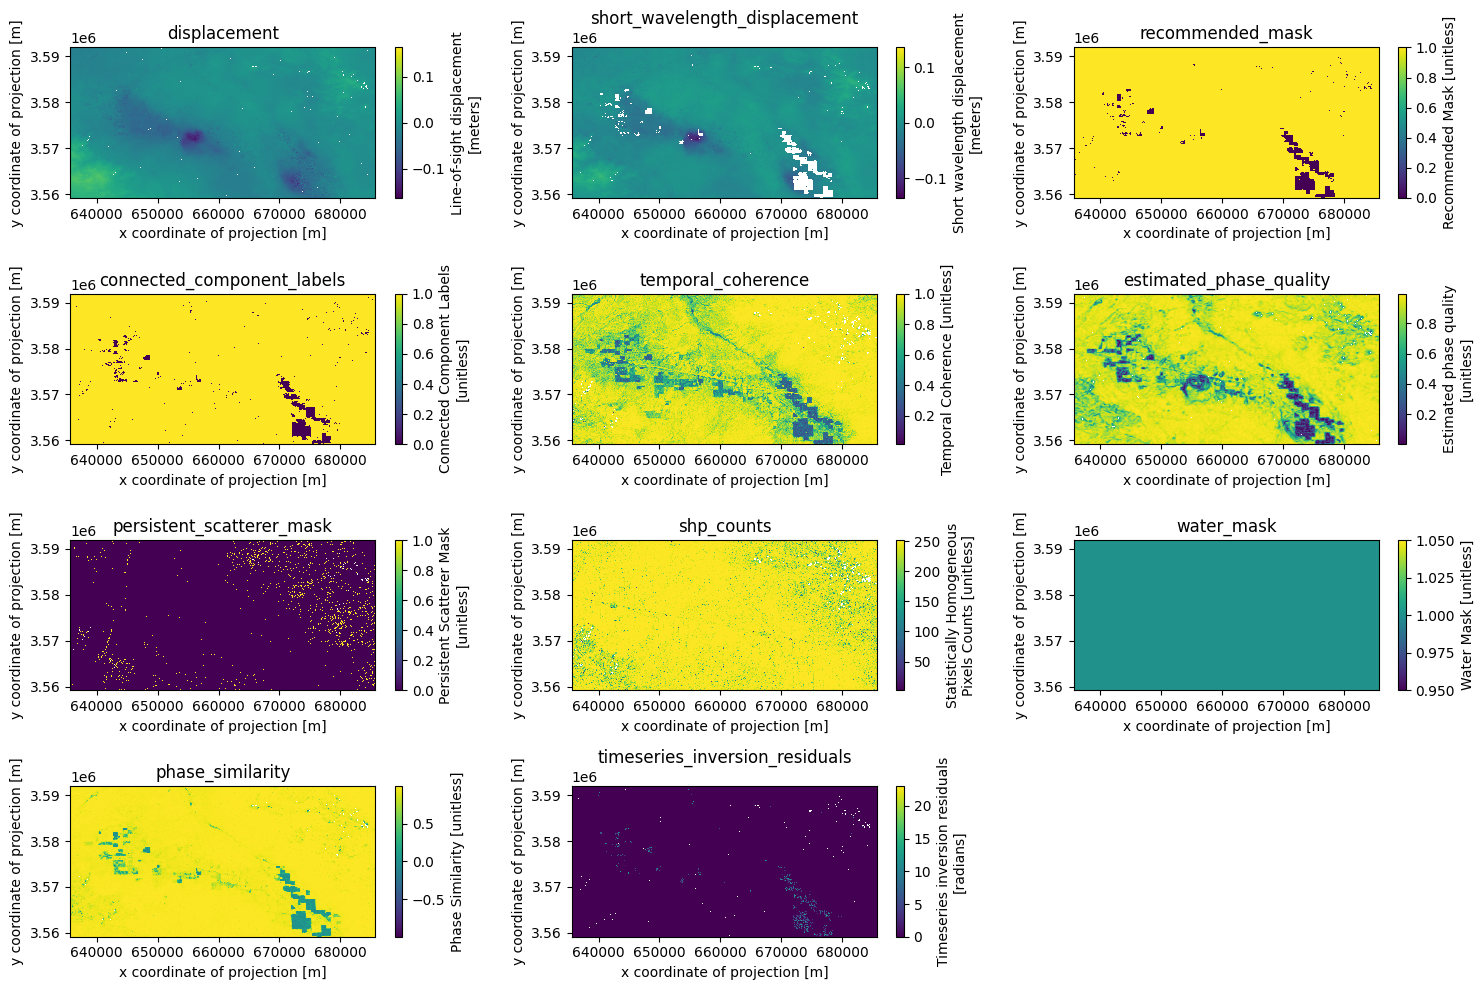

In [14]:
# List all data variables
variables = list(ds.data_vars.keys())
print(f"Variables in dataset: {variables[2:]}")

# Determine grid layout
num_vars = len(variables[2:])
grid_cols = int(num_vars ** 0.5)
grid_rows = (num_vars // grid_cols) + (num_vars % grid_cols > 0)

# Create a figure with subplots
fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(15, 10))
axes = axes.flatten()

# Loop through variables and plot
for i, var_name in enumerate(variables[2:]):
    data_ = ds[var_name]
    data_.plot(ax=axes[i], cmap="viridis", add_colorbar=True)
    axes[i].set_title(var_name)

# Hide unused subplots
for j in range(num_vars, len(axes)):
    axes[j].set_visible(False)

# Adjust layout and show
plt.tight_layout()
plt.show()

## Quality Metrics

The following step provides a summary of the **spatial quality** of the ministack by computing percentages of pixel characteristics:

- **% Persistent Scatterers (PS)**  
  The fraction of pixels identified as persistent scatterers, i.e., stable points that consistently reflect radar signals and are reliable for long-term displacement monitoring.

- **% Valid Time Series Pixels (recommended_mask)**  
  The proportion of pixels flagged as “good” by the recommended quality mask, combining multiple filters such as coherence, water masking, and phase similarity.

- **% Connected Component Valid (not 0)**  
  Indicates the portion of pixels that are part of a valid, unwrapped phase region (i.e., not isolated or ambiguous).

These percentages provide a diagnostic to assess the **spatial coverage and reliability** of the stack.

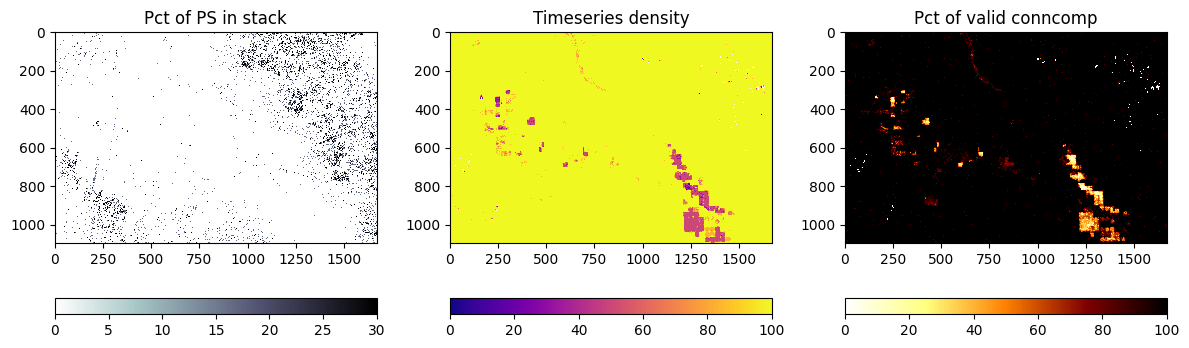

In [15]:
# Check for minimum time steps
stack_quality = stack_prod.chunk({'time': -1})
ref_dates, indices = np.unique(stack_quality.reference_time, return_index=True)
ministack_ref = stack_prod.isel(time=indices).chunk({'time': -1})
if ministack_ref.persistent_scatterer_mask.sizes["time"] <= 2:
    print("Not enough Ministacks steps to compute quality summary. At least 2 required.")

# Compute metrics
pct_ps = quality_metrics.get_value_percentage(ministack_ref.persistent_scatterer_mask.isel(time=slice(1, None)), value=1)
pct_mask = quality_metrics.get_value_percentage(ministack_ref.recommended_mask.isel(time=slice(1, None)), value=1, reverse=False)
pct_conncomp = quality_metrics.get_value_percentage(stack_quality.connected_component_labels.isel(time=slice(1, None)), value=0, reverse=True)
# Plot
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
im1 = ax[0].imshow(np.ma.masked_equal(pct_ps, 0), cmap='bone_r', clim=[0, 30], interpolation='nearest')
im2 = ax[1].imshow(np.ma.masked_equal(pct_mask, 0), cmap='plasma', clim=[0, 100], interpolation='nearest')
im3 = ax[2].imshow(np.ma.masked_equal(pct_conncomp, 0), cmap='afmhot_r', clim=[0, 100], interpolation='nearest')

for a, im in zip(ax, [im1, im2, im3]): fig.colorbar(im, ax=a, location='bottom')

for a, title in zip(ax, ['Pct of PS in stack','Timeseries density','Pct of valid conncomp']): a.set_title(title)

plt.tight_layout()
plt.show()

This following step computes and displays quality indicators for the displacement stack based on metrics derived from the data:

- **Median Temporal Coherence**: Indicates the overall stability of the interferometric signal over time. Higher values suggest more reliable measurements.

- **Median Phase Similarity**: Reflects how consistent the phase is within local neighborhoods. Useful for identifying noisy or unstable areas.

- **Total Number of 2π Phase Jumps**: A diagnostic for phase unwrapping issues. A high count may indicate discontinuities or noise artifacts.

These metrics provide a summary of the stack’s integrity and can help you decide whether to proceed with or filter out unreliable areas.


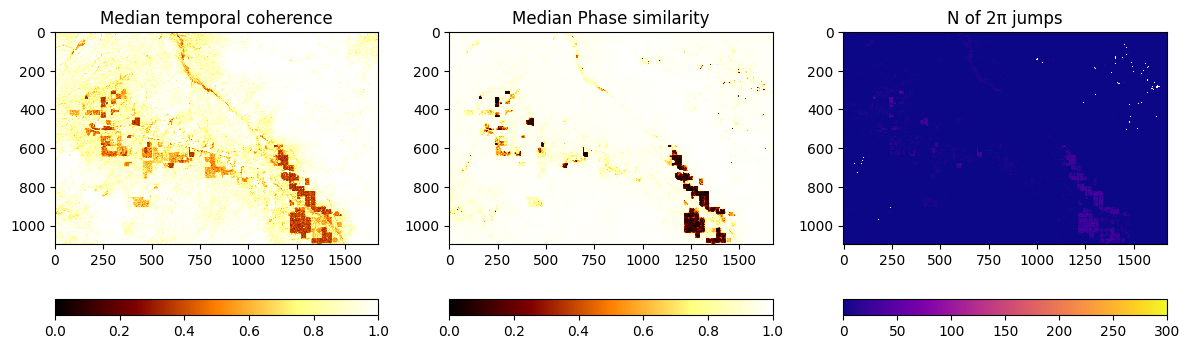

In [16]:
# Compute statistics
median_tcoh = quality_metrics.get_stack_stat(stack_quality.temporal_coherence.isel(time=slice(1, None)), mode='median')
median_psim = quality_metrics.get_stack_stat(stack_quality.phase_similarity.isel(time=slice(1, None)), mode='median')
inv_res_sum = quality_metrics.get_stack_stat(stack_quality.timeseries_inversion_residuals.isel(time=slice(1, None)), mode='sum')
num_2pi_jump = inv_res_sum / (2 * np.pi)

# Plot
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
im1 = ax[0].imshow(np.ma.masked_equal(median_tcoh, 0), cmap='afmhot', clim=[0, 1], interpolation='nearest')
im2 = ax[1].imshow(np.ma.masked_equal(median_psim, 0), cmap='afmhot', clim=[0, 1], interpolation='nearest')
im3 = ax[2].imshow(np.ma.masked_equal(num_2pi_jump, 0), cmap='plasma', clim=[0, 300], interpolation='nearest')

for a, im in zip(ax, [im1, im2, im3]): fig.colorbar(im, ax=a, location='bottom')

for a, title in zip(ax, ['Median temporal coherence', 'Median Phase similarity', 'N of 2π jumps']): a.set_title(title)

plt.tight_layout()
plt.show()


The following step computes and plots statistics related to **`shp_counts`**, which represent the number of statistically homogeneous pixels (SHPs) used in the multilooking process at each pixel.

For the selected ministack, this function reports:
- The median number of SHPs per pixel
- The standard deviation of SHP counts across the scene

These metrics help assess the robustness of the distributed scatterer (DS) processing:
- A higher median indicates more reliable local statistics
- High variability (standard deviation) may point to inconsistent signal quality across the scene

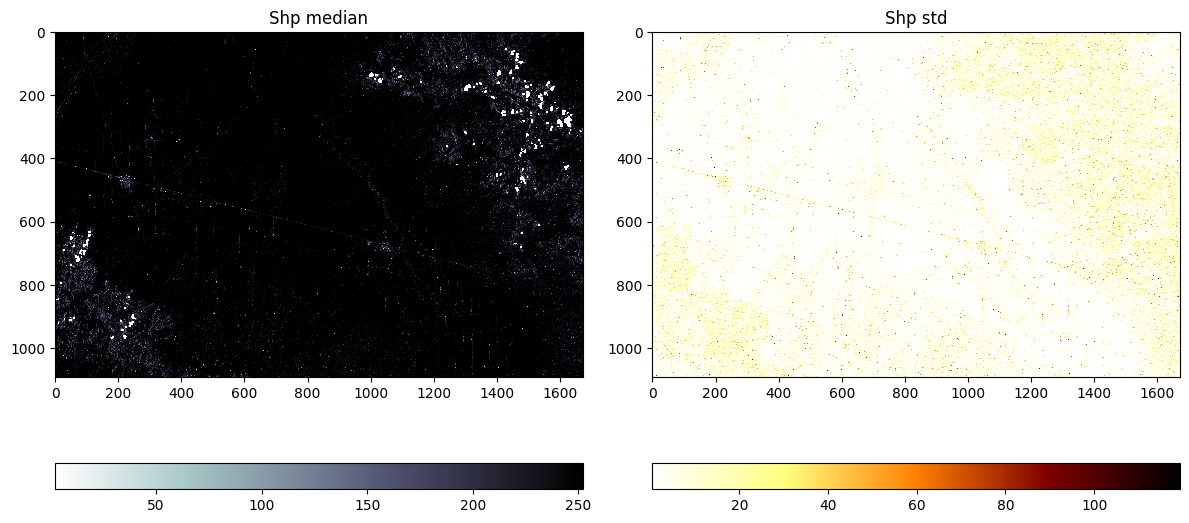

In [17]:
# Check for enough time steps
if ministack_ref.shp_counts.sizes.get("time", 0) <= 2:
    print("Not enough time steps to compute shp stats. At least 2 required.")

# Compute statistics
shp_median = quality_metrics.get_stack_stat(ministack_ref.shp_counts.isel(time=slice(1, None)), mode='median')
shp_std = quality_metrics.get_stack_stat(ministack_ref.shp_counts.isel(time=slice(1, None)), mode='std')

# Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
im1 = ax[0].imshow(np.ma.masked_equal(shp_median, 0), cmap='bone_r', interpolation='nearest')
im2 = ax[1].imshow(np.ma.masked_equal(shp_std, 0), cmap='afmhot_r', interpolation='nearest')

for a, im in zip(ax, [im1, im2]): fig.colorbar(im, ax=a, location='bottom')
for a, txt in zip(ax, ['Shp median', 'Shp std']): a.set_title(txt)
plt.tight_layout()
plt.show()

## Velocity Estimation

This cell computes a linear velocity map (in cm/year) from the displacement time series using least squares fitting.
- Fits a linear model: *displacement = velocity × time + intercept*.
- Colors represent motion in the satellite's line-of-sight (LOS) direction  
  - **Red** indicates motion **away** from the satellite  
  - **Blue** indicates motion **toward** the satellite

In [18]:
# Extract the displacement time series from stack_prod
disp = stack_prod['displacement'].values  # shape: (nt, ny, nx)
times = stack_prod['time'].values         # datetime64 array
ny, nx = disp.shape[1:]                   # spatial dimensions
nt = disp.shape[0]                        # number of time steps

# Convert time to decimal years
def _decimal_year(dates):
    """Convert datetime64 array to decimal years."""
    import pandas as pd
    dates = pd.to_datetime(dates)
    return dates.year + (dates.dayofyear - 1) / 365.25

tdecimal = _decimal_year(times)  # shape (nt,)
A = np.vstack([tdecimal, np.ones_like(tdecimal)]).T  # shape: (nt, 2)

# Reshape displacement to (nt, ny*nx)
y = disp.reshape(nt, -1)

# Solve least squares for linear fit: displacement = velocity * time + intercept
coef, *_ = np.linalg.lstsq(A, y, rcond=None)  # shape: (2, ny*nx)

# Extract velocity (slope) and reshape back to (ny, nx)
vel = coef[0].reshape(ny, nx).astype(np.float32)

# Create new DataArray in xarray
vel_da = xr.DataArray(vel, dims=("y", "x"), coords={"y": stack_prod.y, "x": stack_prod.x},
    attrs={
        "long_name": "Velocity",
        "units": "m/year",
        "description": "Linear velocity estimated from displacement time series",
        "start_date": str(times[0]),
        "end_date": str(times[-1]),
        "ref_date": str(times[0]),
    },
)

# Add it to a new dataset (or optionally merge with stack_prod)
velocity_ds = xr.Dataset({"velocity": vel_da})


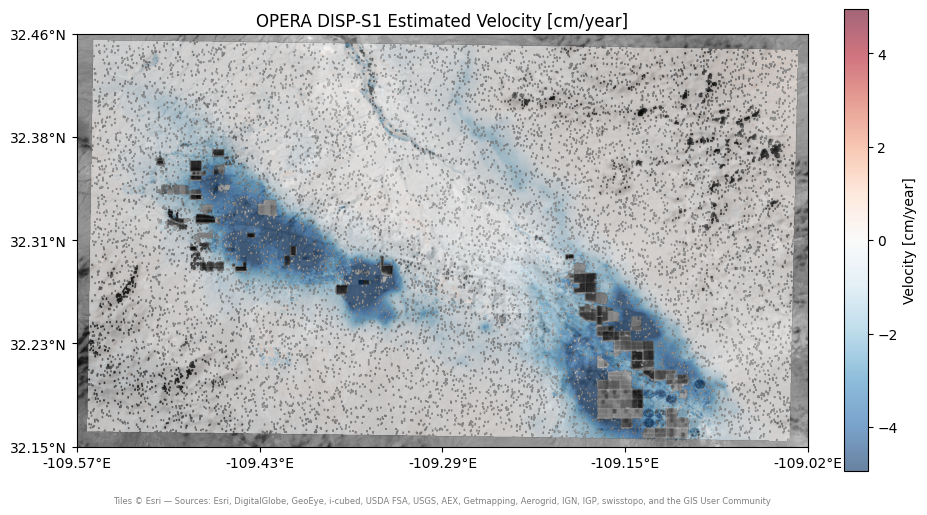

In [19]:
# Convert velocity to cm/year and apply mask
vel_masked = (vel_da * 100).where((stack_prod.isel(time=-1).recommended_mask == 1) & (stack_prod.isel(time=-1).water_mask == 1))

# Reproject to EPSG:4326
vel_masked.rio.write_crs(epsg, inplace=True)
vel_masked.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=True)
vel_4326 = vel_masked.rio.reproject("EPSG:4326", resampling=rasterio.enums.Resampling.bilinear)

# Buffer bounds
buffer_fraction = 0.015
xmin, ymin, xmax, ymax = vel_4326.rio.bounds()
x_pad = (xmax - xmin) * buffer_fraction
y_pad = (ymax - ymin) * buffer_fraction
buffered_bounds = [xmin - x_pad, ymin - y_pad, xmax + x_pad, ymax + y_pad]
extent = [buffered_bounds[0], buffered_bounds[2], buffered_bounds[1], buffered_bounds[3]]

# Normalize values
v = np.nanpercentile(vel_4326.values, [2, 98])
vmax = max(abs(v[0]), abs(v[1]))
vmin = -vmax

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])

# Basemap
bg, bg_extent = get_baseimage_from_bounds(buffered_bounds, source=cx.providers.Esri.WorldImagery, grayscale=True, gamma=0.9)
ax.imshow(bg, extent=bg_extent, cmap="gray", origin="upper", zorder=1)

# Velocity overlay
im = ax.imshow( vel_4326.values, extent=[xmin, xmax, ymin, ymax], cmap="RdBu_r", vmin=vmin, vmax=vmax, alpha=0.6, origin="upper", zorder=2)

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.04)
cbar.set_label("Velocity [cm/year]")

# Ticks and formatting
ax.set_xticks(np.linspace(extent[0], extent[1], 5))
ax.set_yticks(np.linspace(extent[2], extent[3], 5))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.2f}°E"))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:.2f}°N"))
ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)

# Attribution
ax.annotate(
    "Tiles © Esri — Sources: Esri, DigitalGlobe, GeoEye, i-cubed, USDA FSA, USGS, AEX, "
    "Getmapping, Aerogrid, IGN, IGP, swisstopo, and the GIS User Community",
    xy=(0.5, -0.12), xycoords='axes fraction',
    ha='center', va='top', fontsize=6, color='gray'
)

ax.set_title("OPERA DISP-S1 Estimated Velocity [cm/year]")
plt.tight_layout()
plt.show()


## Export DISP-S1 Stack for External Use
This final step prepares your displacement time series for export and use in other tools such as **MintPy**.

The process involves two main actions:

1. **Reformat DISP-S1 Files into a Single NetCDF Stack**  
   - Combines multiple DISP-S1 granules (from a ministack) into a single NetCDF file  
   - Uses a defined reference method (`NONE / MEDIAN / BORDER / POINT /  HIGH COHERENCE`) to re-reference all dates consistently  
   - Drops unnecessary variables like `connected_component_labels`, `shp_counts`, etc. to reduce file size  
   - Output: a single file named `disp-output-<frame_id>.nc`.

2. **Convert to MintPy Format**  
   - Uses the exported NetCDF to generate a MintPy-compatible displacement time series  
   - Produces outputs in the `export/` directory  

In [20]:
# -----------------------------
# DISP-S1 Stack Reformat Script
# -----------------------------

# Set the reference method to one of the following:
#   "NONE"            → No referencing (raw displacement)
#   "POINT"           → Reference to a specific lat/lon location
#   "MEDIAN"          → Median over valid land pixels (excludes water)
#   "BORDER"          → Median over border pixels (configurable size)
#   "HIGH_COHERENCE"  → Median over high-coherence mask (based on threshold)
REFERENCE_METHOD = "BORDER"  # <- Change this line to use a different method

# Output name based on frame ID
OUTPUT_NAME = f"disp-output-{FRAME_ID}.nc"

# Input files
INPUT_FILES = sorted(glob.glob("subset-ncs/*.nc"))
input_files_str = " ".join(INPUT_FILES)

# Execute the reformat command
!opera-utils disp-s1-reformat \
    --drop-vars connected_component_labels shp_counts persistent_scatterer_mask timeseries_inversion_residuals short_wavelength_displacement \
    --reference-method {REFERENCE_METHOD} \
    --output-name {OUTPUT_NAME} \
    --reference-border-pixels 3 \
    --input-files {input_files_str} \
    # Additional reference parameters (uncomment as needed):   
    #--reference-row {row} \
    #--reference-col {col}
    #--reference-lat {lat} \
    #--reference-lon {lon} \     
    # --reference-coherence-threshold 0.7                      # For HIGH_COHERENCE method (default is 0.7

# Convert to MintPy
SAMPLE_FILE = INPUT_FILES[0]
!python -m opera_utils.disp.mintpy {OUTPUT_NAME} \
    --sample-disp-nc {SAMPLE_FILE} \
    --outdir export

!mv {OUTPUT_NAME} export/

Wrote minimal dataset: <xarray.Dataset> Size: 7MB
Dimensions:                 (time: 80, y: 1094, x: 1672)
Coordinates:
  * y                       (y) float64 9kB 3.592e+06 3.592e+06 ... 3.559e+06
  * x                       (x) float64 13kB 6.356e+05 6.357e+05 ... 6.858e+05
  * time                    (time) datetime64[ns] 640B 2022-01-05T13:20:17.97...
Data variables:
    spatial_ref             (time) int64 640B 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    reference_time          (time) datetime64[ns] 640B dask.array<chunksize=(1,), meta=np.ndarray>
    water_mask              (y, x) float32 7MB dask.array<chunksize=(1094, 1672), meta=np.ndarray>
    perpendicular_baseline  (time) float32 320B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    Conventions:         CF-1.8
    contact:             opera-sds-ops@jpl.nasa.gov
    institution:         NASA JPL
    mission_name:        OPERA
    reference_document:  JPL D-108765
    title:               OPERA_L3_DISP-S1 Product
 in 6.1

## Export for GIS & Quick-Look

The following code cell exports your DISP-S1 time series in two formats for further analysis or visualization:

- **Multi-band GeoTIFF Export**  
  A single GeoTIFF is created with one band per acquisition date. Each band contains cumulative displacement from the reference date to the corresponding acquisition.  
  This file can be opened in GIS software such as QGIS or ArcGIS Pro.

- **PNG Snapshots**  
  One PNG is generated per acquisition date to provide a quick visual overview of displacement evolution.  
  All images use a consistent, symmetric color scale centered on zero, determined from the final (most cumulative) image.

In [21]:
output_dir = "export"
displacement_var = "displacement"
input_nc = os.path.join(output_dir, OUTPUT_NAME)
output_tif = os.path.join(output_dir, f"OPERA-DISP-S1_Frame_{FRAME_ID}_displacement_timeseries.tif")

ds_full = xr.open_dataset(input_nc)
disp = ds_full[displacement_var]
dates = ds_full["time"].dt.strftime('%Y-%m-%dT%H:%M:%S').values

height, width = disp.shape[1], disp.shape[2]
transform = rasterio.transform.from_origin(ds_full.x[0], ds_full.y[0], np.abs(ds_full.x[1] - ds_full.x[0]), np.abs(ds_full.y[1] - ds_full.y[0]))
crs = ds_full.spatial_ref.attrs.get("crs_wkt") or ds_full.spatial_ref.attrs.get("spatial_ref")

with rasterio.open(output_tif, "w", driver="GTiff", count=disp.shape[0], height=height, width=width, dtype=disp.dtype, 
                   crs=crs, transform=transform, nodata=np.nan, compress="DEFLATE", tiled=True, predictor=2, bigtiff="YES", 
                   zlevel=4,) as dst:
    for i in range(disp.shape[0]):
        dst.write(disp[i, :, :].values.astype(np.float32), i + 1)

with rasterio.open(output_tif, "r+") as ds_edit:
    for i, date in enumerate(dates):
        ds_edit.set_band_description(i + 1, f"Time series: {date}")


In [22]:
## Export PNGs for each time step
output_dir_pics = os.path.join(output_dir, "pics")
os.makedirs(output_dir_pics, exist_ok=True)
dates = ds_full["time"].dt.strftime('%Y%m%d').values
ref_date = ds_full['reference_time'].dt.strftime('%Y%m%d').values[0]

vmin_raw = np.nanpercentile(disp[-1], 1)
vmax_raw = np.nanpercentile(disp[-1], 99)
max_abs_val = max(abs(vmin_raw), abs(vmax_raw))
vmin, vmax = -max_abs_val, max_abs_val

file_paths = []
for i, date in enumerate(dates):
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(disp[i].values, cmap="jet", origin="upper", vmin=vmin, vmax=vmax)
    ax.set_title(f"OPERA-DISP-S1 Frame {FRAME_ID} -- Displacement from {dates[0]} to {date}")
    plt.colorbar(im, ax=ax, label="Displacement (m)")
    png_path = os.path.join(output_dir_pics, f"OPERA-DISP-S1_Frame_{FRAME_ID}_displacement_from_{ref_date}_to_{date}.png")
    plt.savefig(png_path, bbox_inches="tight")
    plt.close(fig)
    file_paths.append(png_path)

print(f'PNG Saved in /{output_dir_pics} directory')

PNG Saved in /export/pics directory


EOF